# Project 11 - Multi-Agent Workflows

**A self-explanatory Kaggle notebook.** Each code cell is explained in plain English above it.

Real automation comes from a **team of specialised agents** - a planner, researchers, a writer, a
critic - that pass work between each other, not one agent doing everything. We build a runnable
multi-agent **pipeline** with shared state and a **critic loop** (rule-based stand-ins so it runs
with no API key), then give you the production LangGraph/CrewAI code.

**What you'll learn**
- **Agent roles** and why dividing labour beats one do-everything agent.
- **Shared state** and **handoffs**: how agents pass work along a graph.
- A **critic/verifier** agent that reviews and sends work back for revision - and measurably
  improves quality.

## The scenario
You want an automated "research analyst" that, given a topic, produces a short, well-rounded
brief. One agent tends to forget parts or write sloppily. A **crew** - plan the angles, research
each, write a draft, then critique and revise - produces something far more reliable. We'll watch
that crew work, and watch the critic catch a gap and fix it.

## Foundations (plain English)
- **Role specialisation:** each agent has one job and its own instructions (planner, researcher,
  writer, critic). Focused agents make fewer mistakes than one generalist.
- **Shared state:** a single object (here a Python dict) carries the goal, the plan, the findings,
  and the draft as work flows between agents.
- **Orchestration:** the order and control flow - here a pipeline with a **loop-back** from the
  critic to the writer when the draft isn't good enough.
- **Critic / verifier:** a dedicated checker that reviews output before it's finalised - one of the
  biggest reliability wins in agentic systems.

### Cell 1 - a tiny knowledge base + the shared state
The researchers will look facts up here. The `state` dict is what every agent reads and writes.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

KB = {
 "benefits":   "Renewable energy cuts greenhouse emissions and lowers long-run costs.",
 "challenges": "Its main challenges are intermittency and high upfront capital.",
 "examples":   "Solar and wind are the fastest-growing renewable sources worldwide.",
}
state = {"goal": "Write a short brief on renewable energy.",
         "subtasks": [], "findings": {}, "draft": "", "review": "", "log": []}
print("knowledge base topics:", list(KB))

knowledge base topics: ['benefits', 'challenges', 'examples']


### Cell 2 - the four agents (each one small and focused)
`planner` chooses the angles to cover. `researcher` fetches a fact per angle. `writer` drafts the
brief - but on its FIRST attempt it (deliberately) forgets the last topic, so we can see the critic
catch it. `critic` checks every planned topic is present and approves or requests a revision.

In [2]:
def planner(state):
    state["subtasks"] = ["benefits", "challenges", "examples"]   # the angles to cover
    state["log"].append(("planner", f"plan = {state['subtasks']}"))

def researcher(state):
    for t in state["subtasks"]:
        state["findings"][t] = KB.get(t, "(no data)")
    state["log"].append(("researcher", f"gathered {len(state['findings'])} findings"))

def writer(state, revision):
    topics = state["subtasks"] if revision else state["subtasks"][:-1]   # v1 forgets the last topic
    state["draft"] = " ".join(state["findings"][t] for t in topics)
    state["log"].append(("writer", f"draft covers {len(topics)} of {len(state['subtasks'])} topics"))

def critic(state):
    missing = [t for t in state["subtasks"] if state["findings"][t] not in state["draft"]]
    approved = len(missing) == 0
    state["review"] = "approved" if approved else f"missing topics: {missing}"
    state["log"].append(("critic", state["review"]))
    return approved
print("agents defined")

agents defined


### Cell 3 - run the crew (pipeline + critic loop-back)
Plan -> research -> (write -> critique) with a loop: if the critic isn't satisfied, the writer
revises. We cap revisions (a guardrail). Watch the log: the critic catches the missing topic on
attempt 1 and the writer fixes it on attempt 2.

In [3]:
coverage = []
planner(state)
researcher(state)
for attempt in range(3):                      # max 3 attempts = guardrail
    writer(state, revision=attempt)
    covered = sum(state["findings"][t] in state["draft"] for t in state["subtasks"])
    coverage.append(covered)
    if critic(state):
        break

print("=== who did what ===")
for who, what in state["log"]:
    print(f"  {who:11s}: {what}")
print("\n=== FINAL BRIEF ===\n" + state["draft"])

=== who did what ===
  planner    : plan = ['benefits', 'challenges', 'examples']
  researcher : gathered 3 findings
  writer     : draft covers 2 of 3 topics
  critic     : missing topics: ['examples']
  writer     : draft covers 3 of 3 topics
  critic     : approved

=== FINAL BRIEF ===
Renewable energy cuts greenhouse emissions and lowers long-run costs. Its main challenges are intermittency and high upfront capital. Solar and wind are the fastest-growing renewable sources worldwide.


### Cell 4 - diagram: the agent graph
The crew is a small graph: Planner -> Researcher -> Writer -> Critic, with the Critic looping back
to the Writer until the draft is approved, then finishing.

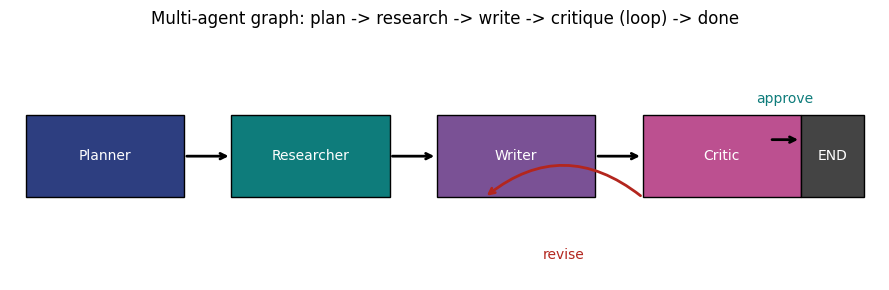

In [4]:
fig, ax = plt.subplots(figsize=(9,3)); ax.axis("off"); ax.set_xlim(0,11); ax.set_ylim(0,3)
names = ["Planner","Researcher","Writer","Critic"]; colors=["#2d3e80","#0e7c7b","#7a5195","#bc5090"]
for i,(n,c) in enumerate(zip(names,colors)):
    ax.add_patch(plt.Rectangle((i*2.6+0.2,1),2,1,facecolor=c,edgecolor="black"))
    ax.text(i*2.6+1.2,1.5,n,ha="center",va="center",color="white",fontsize=10)
    if i<3: ax.annotate("",(i*2.6+2.8,1.5),(i*2.6+2.2,1.5),arrowprops=dict(arrowstyle="->",lw=2))
# critic -> writer (revise) and critic -> END (approve)
ax.annotate("",(6.0,1.0),(8.0,1.0),arrowprops=dict(arrowstyle="->",lw=2,color="#b3261e",connectionstyle="arc3,rad=0.4"))
ax.text(7.0,0.25,"revise",ha="center",color="#b3261e")
ax.add_patch(plt.Rectangle((10.0,1),0.8,1,facecolor="#444",edgecolor="black")); ax.text(10.4,1.5,"END",ha="center",va="center",color="white")
ax.annotate("",(10.0,1.7),(9.6,1.7),arrowprops=dict(arrowstyle="->",lw=2)); ax.text(9.8,2.15,"approve",ha="center",color="#0e7c7b")
ax.set_title("Multi-agent graph: plan -> research -> write -> critique (loop) -> done"); plt.tight_layout(); plt.show()

### Cell 5 - diagram: the critic loop improved coverage
Topics covered by the draft on each attempt. Attempt 1 misses a topic; the critic sends it back;
attempt 2 covers everything. That jump is the value a verifier agent adds.

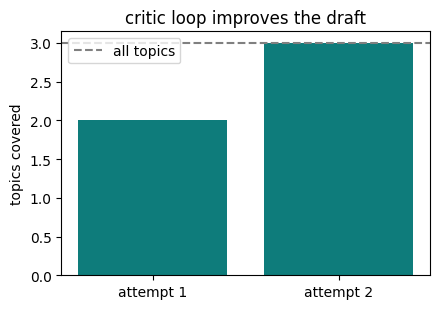

In [5]:
plt.figure(figsize=(4.5,3.2))
plt.bar([f"attempt {i+1}" for i in range(len(coverage))], coverage, color="#0e7c7b")
plt.axhline(len(state["subtasks"]), ls="--", color="grey", label="all topics")
plt.ylabel("topics covered"); plt.title("critic loop improves the draft"); plt.legend()
plt.tight_layout(); plt.show()

## The real thing - LangGraph / CrewAI (Kaggle / your machine)
Replace the rule-based agents with real LLM agents that share a typed state in a graph.

```python
# pip install langgraph langchain-openai
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

class State(TypedDict):
    goal: str; plan: List[str]; findings: List[str]; draft: str; review: str

def planner(s):    s["plan"]    = llm.invoke(f"List 3 angles for: {s['goal']}").content.split("\n"); return s
def researcher(s): s["findings"]= [llm.invoke(f"Research: {a}").content for a in s["plan"]];           return s
def writer(s):     s["draft"]   = llm.invoke(f"Write a brief from: {s['findings']}").content;          return s
def critic(s):     s["review"]  = llm.invoke(f"Critique this draft, say APPROVED or REVISE: {s['draft']}").content; return s

g = StateGraph(State)
for name, fn in [("planner",planner),("researcher",researcher),("writer",writer),("critic",critic)]:
    g.add_node(name, fn)
g.set_entry_point("planner")
g.add_edge("planner","researcher"); g.add_edge("researcher","writer"); g.add_edge("writer","critic")
g.add_conditional_edges("critic", lambda s: "writer" if "REVISE" in s["review"] else END)  # loop-back
app = g.compile()
print(app.invoke({"goal": "Write a brief on renewable energy."})["draft"])
```

**Make it production-grade:** budget the iterations and cost, run agents in parallel where possible
(e.g. several researchers), add a human-approval node for the final output, and evaluate the crew
against a single-agent baseline (quality vs cost) in W&B.

## What just happened (recap)
- Four focused agents shared one **state** and handed work along a **graph**.
- The **critic** caught a missing topic and looped the draft back for revision - coverage went from
  partial to complete (you saw the bar jump).
- Production systems do this with LangGraph/CrewAI, real LLM agents, budgets, and parallelism.

## Scenarios & your turn
- **Add a topic** to the plan and watch research/writing/critique adapt.
- **Add a second researcher** that runs in parallel and merge findings.
- **Tighten the critic** (e.g. require a minimum length) and see more revision loops.
- **Project goal:** build a real research-analyst crew, compare it to a single agent, and ship a
  demo where users enter a topic and watch the crew work.

## Mini-glossary
**role specialisation** one job per agent - **shared state** the object passed between agents -
**handoff** passing work along - **orchestration** the control flow/graph - **supervisor** an agent
that routes work - **critic/verifier** reviews before finalising - **loop-back** send work for
revision.